## Prediction code for the whole cube
<div style="text-align: right;">
<b>Authors:
    Yang Cui & Alessandro</b>
</div>

## import library

In [1]:
import warnings
import sys
import os
warnings.filterwarnings('ignore')
sys.path.append('../')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt
import time
import cigsegy
from cigsegy import SegyNP

from ufno_new_1 import *
from utils import *
from eva_metrics import *
from pylops.basicoperators import *



# # Check for CUDA availability and set the device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")


torch.manual_seed(0)
np.random.seed(0)
# # Make a new dir to save figs
fig_path =  "../figs/cube_test/res_free_test/"

# # Create the directory, including any necessary parent directories
os.makedirs(fig_path, exist_ok=True)

<Figure size 600x600 with 0 Axes>

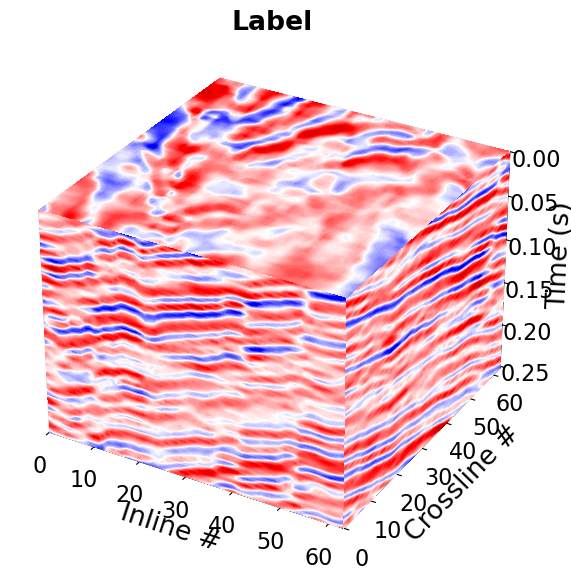

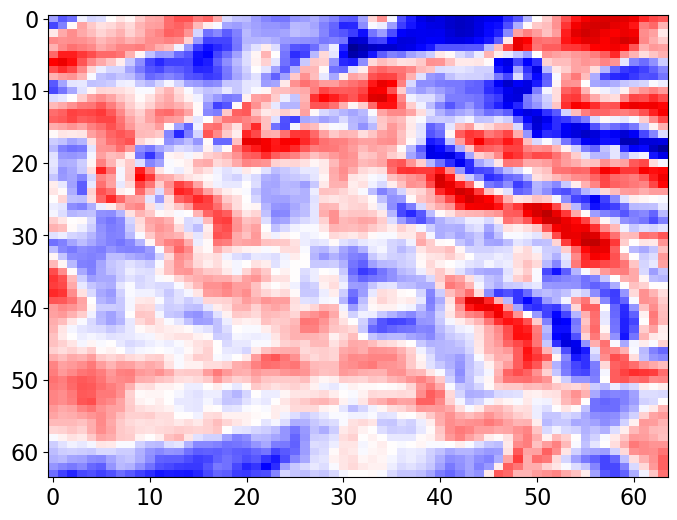

In [2]:
kerry_data = np.load('../data/test_cubes/kerry_64x64x64.npy')
# kerry_data = np.load('../data/test_cubes/kerry_128x128x128.npy')
cube_visual(kerry_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)",
            title='Label', save_path=f'{fig_path}res_free_64_kerry_label.png')
v=4
plt.imshow(kerry_data[32, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

## Missing

<Figure size 600x600 with 0 Axes>

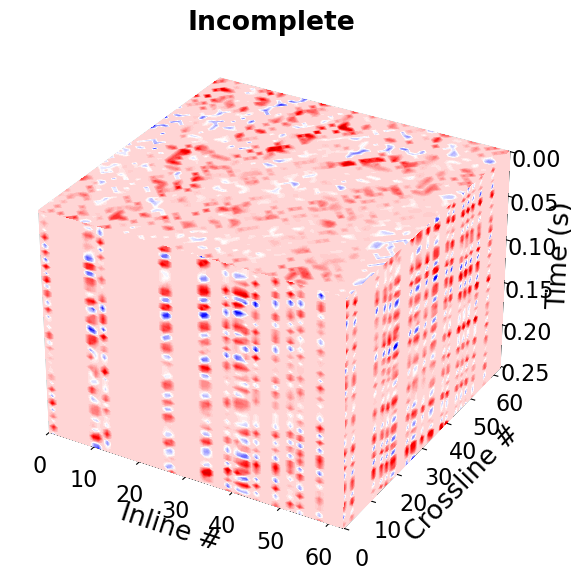

In [3]:
[in1, in2, in3] = kerry_data.shape
# the ratio of missing trace equal to 1-ratio
ratio = 0.3

## generate random mask
mask=genmask(kerry_data.reshape(in1,in2*in3,order='F'),ratio,'c',202412)
mask=mask.reshape(in1,in2,in3,order='F')
rand_mask_cube = kerry_data*mask
incom_kerry_data = rand_mask_cube
cube_visual(incom_kerry_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)",
            title='Incomplete', save_path=f'{fig_path}res_free_64_kerry_incomplete.png')

## Prediction

In [7]:
mode1 = 12
mode2 = 12
mode3 = 12
width = 16

input_data = np.reshape(incom_kerry_data, [1, incom_kerry_data.shape[0], incom_kerry_data.shape[1], 
                                                       incom_kerry_data.shape[2]])
# Convert to PyTorch tensors
X = torch.Tensor(input_data).unsqueeze(-1).to(device)
print(X.shape)

model = Net3d(mode1, mode2, mode3, width).to(device)
model.load_state_dict(torch.load('../model/UFNO_3D_recon_all_modes12_width16_ep200_num750_new_bn.pth'))

torch.Size([1, 64, 64, 64, 1])


<All keys matched successfully>

<Figure size 600x600 with 0 Axes>

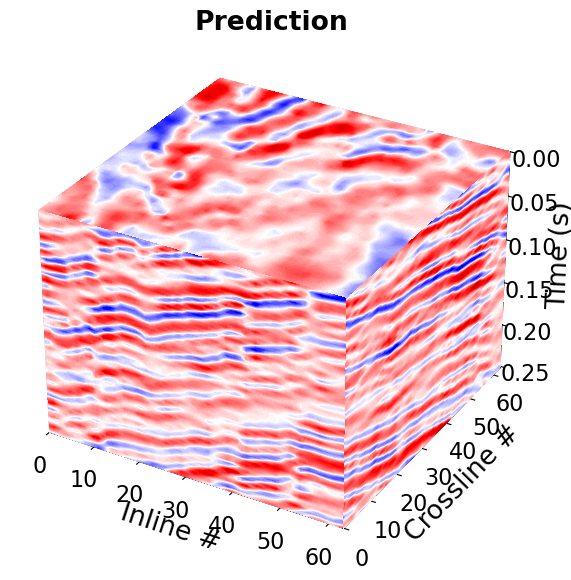

<Figure size 600x600 with 0 Axes>

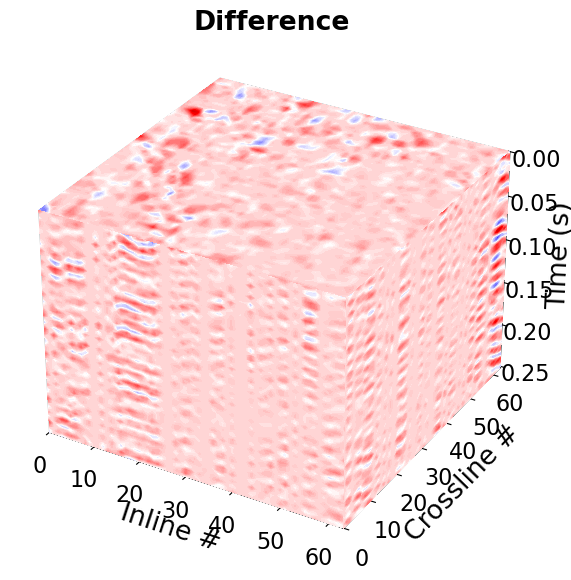

In [8]:
# Prediction
prediction = model(X)
output_data = prediction.cpu().detach().numpy()
output_data.shape

cube_visual(output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
            title='Prediction', save_path=f'{fig_path}res_free_64_kerry_pred.png')
cube_visual(kerry_data-output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
            title='Difference', save_path=f'{fig_path}res_free_64_kerry_diff.png')

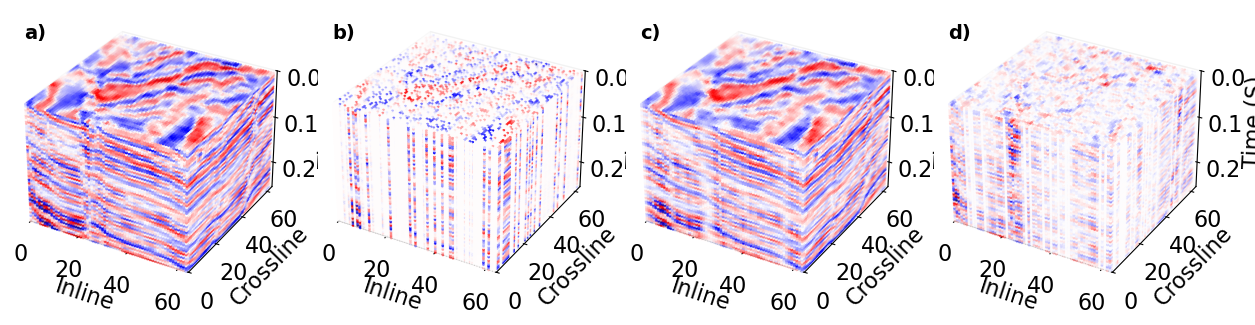

In [10]:
data = [kerry_data, incom_kerry_data, output_data, kerry_data-output_data]

# Define spatial parameters
deltaz = 0.004
deltax = deltay = 1
zmin = xmin = ymin = 0

cube_shape = kerry_data.shape
xmax = cube_shape[0] * deltax
ymax = cube_shape[1] * deltay
zmax = cube_shape[2] * deltaz

# Generate coordinate arrays with z inverted from the start
z = np.linspace(zmax, zmin, cube_shape[2], endpoint=False)  # zmax first for inversion
x = np.linspace(xmin, xmax, cube_shape[0], endpoint=False)
y = np.linspace(ymin, ymax, cube_shape[1], endpoint=False)

# Create meshgrid
Z, X, Y = np.meshgrid(z, x, y, indexing='ij')

# Create figure
fig = plt.figure(figsize=(14, 4))

for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    
    # Plot ALL points without downsampling
    sc = ax.scatter(
        X.flatten(), Y.flatten(), Z.flatten(),  # Removed idx and step
        c=data[i].flatten(), 
        cmap='seismic', 
        vmin=-5, 
        vmax=5, 
        s=1.5
    )
    
    # Axis labels and inversion
    ax.set_xlabel('Inline')
    ax.set_ylabel('Crossline')
    ax.set_zlabel('Time (S)')
    ax.invert_zaxis()  # Visual inversion
    ax.set_zlim(zmax, zmin)  # Matches the coordinate generation
    
    # Visual formatting
    ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = False
    
    # Subplot label
    ax.text2D(0.05, 0.95, f"{chr(97 + i)})", transform=ax.transAxes,
             fontsize=14, fontweight='bold', va='top', ha='left')
    
    # Set consistent limits
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

# Adjust layout
fig.subplots_adjust(left=0.0, right=0.86, top=1, bottom=0.01, wspace=0.1, hspace=0.01)
plt.savefig(f'{fig_path}kerry_64_3d_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
label = kerry_data
test_data = incom_kerry_data
mse_0 = mse_cal(label, test_data)
mse_1 = mse_cal(label, output_data)
snr_0, psnr_0 = calculate_snr_psnr(label, test_data)
snr_1, psnr_1 = calculate_snr_psnr(label, output_data)
ssim_0 = compute_3d_ssim(label, test_data, patch_size=10)
ssim_1 = compute_3d_ssim(label, output_data, patch_size=10)
fd_0 = FrechetDistances(label, test_data)
fd_1 = FrechetDistances(label, output_data)


print(f'MSE incomplete: {mse_0:.3f}\tMSE recon: {mse_1:.3f}')
print(f'SNR incomplete: {snr_0:.3f} dB\tSNR recon: {snr_1:.3f} dB')
print(f'PSNR incomplete: {psnr_0:.3f} dB\tPSNR recon: {psnr_1:.3f} dB')
print(f'SSIM incomplete: {ssim_0:.3f} \t SSIM recon: {ssim_1:.3f}')
print(f'FD incomplete: {fd_0:.3f} \t FD recon: {fd_1:.3f}')

MSE incomplete: 0.919	MSE recon: 0.115
SNR incomplete: 1.542 dB	SNR recon: 10.572 dB
PSNR incomplete: 13.211 dB	PSNR recon: 22.241 dB
SSIM incomplete: 0.366 	 SSIM recon: 0.936
FD incomplete: 0.519 	 FD recon: 0.115


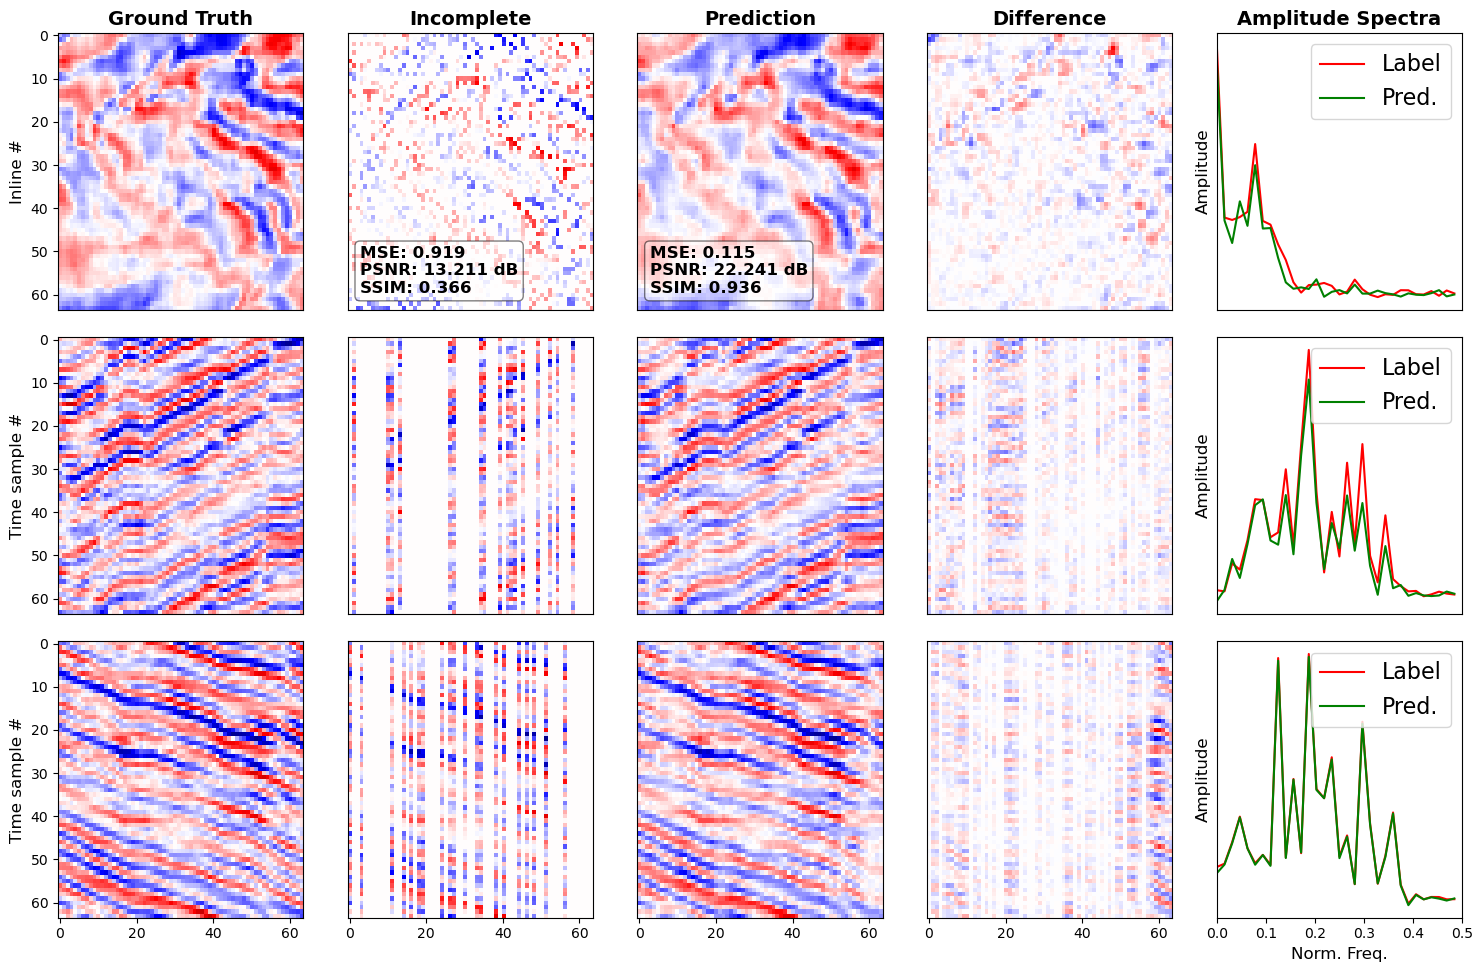

In [13]:
v = 5 # Set amplitude limit for color scaling
fig, axs = plt.subplots(3, 5, figsize=(15, 10))
time_num, xline_num, iline_num = 32, 32, 32
incomplete = incom_kerry_data
prediction = output_data
trace_num = 48
# Time Slice
# Time Slice
axs[0, 0].imshow(label[time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 0].set_title("Ground Truth", fontweight='bold', fontsize=14)
axs[0, 0].set_ylabel('Inline #', fontsize=12)
axs[0, 0].tick_params(axis='both', labelsize=10)  # Smaller fontsize for ticks

axs[0, 1].imshow(incomplete[time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 1].set_title("Incomplete", fontweight='bold', fontsize=14)
axs[0, 1].text(0.05, 0.05, 
               f"MSE: {mse_0:.3f}\nPSNR: {psnr_0:.3f} dB\nSSIM: {ssim_0:.3f}",
               ha='left', va='bottom', fontsize=12, fontweight='bold', transform=axs[0, 1].transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 1].tick_params(axis='both', labelsize=10)

axs[0, 2].imshow(prediction[time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 2].set_title("Prediction", fontweight='bold', fontsize=14)
axs[0, 2].text(0.05, 0.05, 
               f"MSE: {mse_1:.3f}\nPSNR: {psnr_1:.3f} dB\nSSIM: {ssim_1:.3f}",
               ha='left', va='bottom', fontsize=12, fontweight='bold', transform=axs[0, 2].transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axs[0, 2].tick_params(axis='both', labelsize=10)

axs[0, 3].imshow(label[time_num, :, :] - prediction[time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 3].set_title("Difference", fontweight='bold', fontsize=14)
axs[0, 3].tick_params(axis='both', labelsize=10)

# Amplitude Spectra for Time Slice
trace_data_pred = prediction[time_num, trace_num, :]
trace_data_label = label[time_num, trace_num, :]
n = len(trace_data_label)
freq = np.fft.fftfreq(n)[:n//2]  # Positive frequencies only
amp_label = np.abs(np.fft.fft(trace_data_label))[:n//2] / n  # Normalized amplitude
amp_pred = np.abs(np.fft.fft(trace_data_pred))[:n//2] / n
axs[0, 4].plot(freq, amp_label, 'r', label="Label")
axs[0, 4].plot(freq, amp_pred, 'g', label="Pred.")
axs[0, 4].set_title("Amplitude Spectra", fontweight='bold', fontsize=14)
# axs[0, 4].set_xlabel('Frequency', fontsize=12)
axs[0, 4].set_ylabel('Amplitude', fontsize=12)
axs[0, 4].set_xlim(0, 0.5)  # Display up to Nyquist frequency
axs[0, 4].tick_params(axis='both', labelsize=10)
axs[0, 4].legend()

# Inline Slice
axs[1, 0].imshow(label[:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[1, 0].set_ylabel('Time sample #', fontsize=12)
axs[1, 0].tick_params(axis='both', labelsize=10)

axs[1, 1].imshow(incomplete[:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[1, 1].tick_params(axis='both', labelsize=10)

axs[1, 2].imshow(prediction[:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[1, 2].tick_params(axis='both', labelsize=10)

axs[1, 3].imshow(label[:, :, xline_num] - prediction[:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[1, 3].tick_params(axis='both', labelsize=10)

# Amplitude Spectra for Inline Slice
trace_data_pred = prediction[:, trace_num, xline_num]
trace_data_label = label[:, trace_num, xline_num]
n = len(trace_data_label)
freq = np.fft.fftfreq(n)[:n//2]
amp_label = np.abs(np.fft.fft(trace_data_label))[:n//2] / n
amp_pred = np.abs(np.fft.fft(trace_data_pred))[:n//2] / n
axs[1, 4].plot(freq, amp_label, 'r', label="Label")
axs[1, 4].plot(freq, amp_pred, 'g', label="Pred.")
# axs[1, 4].set_xlabel('Frequency', fontsize=12)
axs[1, 4].set_ylabel('Amplitude', fontsize=12)
axs[1, 4].set_xlim(0, 0.5)
axs[1, 4].tick_params(axis='both', labelsize=10)
axs[1, 4].legend()

# Crossline Slice
axs[2, 0].imshow(label[:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[2, 0].set_ylabel('Time sample #', fontsize=12)
axs[2, 0].tick_params(axis='both', labelsize=10)

axs[2, 1].imshow(incomplete[:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[2, 1].tick_params(axis='both', labelsize=10)

axs[2, 2].imshow(prediction[:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[2, 2].tick_params(axis='both', labelsize=10)

axs[2, 3].imshow(label[:, iline_num, :] - prediction[:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[2, 3].tick_params(axis='both', labelsize=10)

# Amplitude Spectra for Crossline Slice
trace_data_pred = prediction[:, iline_num, trace_num]
trace_data_label = label[:, iline_num, trace_num]
n = len(trace_data_label)
freq = np.fft.fftfreq(n)[:n//2]
amp_label = np.abs(np.fft.fft(trace_data_label))[:n//2] / n
amp_pred = np.abs(np.fft.fft(trace_data_pred))[:n//2] / n
axs[2, 4].plot(freq, amp_label, 'r', label="Label")
axs[2, 4].plot(freq, amp_pred, 'g', label="Pred.")
axs[2, 4].set_xlabel('Norm. Freq.', fontsize=12)
axs[2, 4].set_ylabel('Amplitude', fontsize=12)
axs[2, 4].set_xlim(0, 0.5)
axs[2, 4].tick_params(axis='both', labelsize=10)
axs[2, 4].legend()

# Remove y-ticks except for the first column
for ax in axs[:, 1:].flatten():
    ax.set_yticks([])

# Remove x-ticks except for the last row
for ax in axs[:-1, :].flatten():
    ax.set_xticks([])
# Adjust layout
plt.tight_layout()

plt.savefig(f'{fig_path}kerry_64_2D_ratio{1-ratio}_t{time_num}_i{iline_num}_c{xline_num}.png', format='png', dpi=300)
plt.show()